# WETH/USDT Uniswap V3 LP 데이터 EDA

고정 WETH/USDT 0.05% pool의 operation pair, non-same-block realized-fee return, Binance ETHUSDT, FRED SOFR를 한 번에 점검한다. 이 notebook은 외부 data root를 읽기만 하며 분석 결과 파일을 쓰지 않는다.

분석 순서와 표본 정의:

- 전체 snapshot의 raw event와 position reconstruction funnel을 먼저 보고한다.
- fee identity interval이 겹치는 11개 operation pair는 비례 배분 없이 모집단에서 먼저 제거한다.
- 전체 analytical pair 모집단은 41,660개이며 same-block과 multi-block으로 나눈다.
- 경계 편향을 줄이기 위한 EDA 기간은 `[2021-07-01, 2026-07-01)`이다. Entry와 exit가 모두 이 구간에 있는 완전 관측 pair만 기간 표본에 포함한다.
- lifetime, size, fee, return 분석은 기간 표본 중 same-block을 제외한 10,158개를 사용한다.

Observed realized fee는 보유 중 실제 Collect와 exit transaction에서 Burn principal을 초과해 Collect된 금액을 합한다. `fee_complete_exact`였던 position도 이 값에 포함되며 별도 cohort로 표시하지 않는다. Exit Collect가 없으면 exit realized fee는 0이다. 모든 fee는 exit price로 평가하며 gas는 제외한다.

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import pyarrow.parquet as pq
from IPython.display import display

working_directory = Path.cwd().resolve()
REPOSITORY_ROOT = next(
    (path for path in (working_directory, *working_directory.parents) if (path / 'data' / 'src').is_dir()),
    None,
)
if REPOSITORY_ROOT is None:
    raise RuntimeError('Could not locate the repository root from the notebook working directory.')
sys.path.insert(0, str(REPOSITORY_ROOT / 'data' / 'src'))
from uniswap_v3_data.paths import resolve_data_root

DATA_ROOT = resolve_data_root()
DATASET_ID = json.loads((REPOSITORY_ROOT / 'data' / 'manifest.json').read_text())['dataset_id']
RAW_EVENT_ROOT = DATA_ROOT / 'raw' / 'bigquery' / DATASET_ID / 'events'
PAIR_ROOT = DATA_ROOT / 'derived' / 'operation_pairs'
POSITIONS_PATH = DATA_ROOT / 'derived' / 'positions' / 'all_target_positions.parquet'
RETURN_PATH = DATA_ROOT / 'derived' / 'returns' / 'non_same_block_pair_returns.parquet'
POOL_EVENT_ROOT = DATA_ROOT / 'processed' / 'pool_events'
NFPM_EVENT_ROOT = DATA_ROOT / 'processed' / 'nfpm_events'
POOL_DAILY_PATH = DATA_ROOT / 'processed' / 'pool_daily' / 'pool_daily.parquet'
ORACLE_ROOT = DATA_ROOT / 'external' / 'oracle' / 'binance_ethusdt_1s'
QC_PATH = DATA_ROOT / '.runs' / 'processing' / 'build_pair_returns_qc.json'
ANALYSIS_START = pd.Timestamp('2021-07-01', tz='UTC')
ANALYSIS_END = pd.Timestamp('2026-07-01', tz='UTC')

required = [RAW_EVENT_ROOT, POSITIONS_PATH, PAIR_ROOT / 'all_pairs.parquet', RETURN_PATH, POOL_DAILY_PATH, ORACLE_ROOT / 'manifest.json']
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing inputs: {missing}. Run: python data/scripts/dataset.py build-pair-returns')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.6g}')
print('External data root resolved successfully.')

External data root resolved successfully.


## 1. 전체 snapshot의 raw event와 decoded event count

Raw layer는 target pool과 canonical NFPM contract의 log를 함께 보존한다. Event별 count는 동일 raw log를 decode한 processed layer에서 집계하며, 각 source 내부 비율을 함께 표시한다.

In [2]:
def count_event_types(paths):
    counts = Counter()
    rows = 0
    for path in sorted(paths):
        values = pq.read_table(path, columns=['event_type']).column('event_type').to_pylist()
        counts.update(values)
        rows += len(values)
    return rows, counts

raw_event_paths = sorted(RAW_EVENT_ROOT.glob('*.parquet'))
raw_rows = sum(pq.ParquetFile(path).metadata.num_rows for path in raw_event_paths)
pool_rows, pool_counts = count_event_types(POOL_EVENT_ROOT.glob('*.parquet'))
nfpm_rows, nfpm_counts = count_event_types(NFPM_EVENT_ROOT.glob('*.parquet'))
event_counts = pd.concat([
    pd.DataFrame({'source': 'Target pool', 'event_type': list(pool_counts), 'count': list(pool_counts.values())}),
    pd.DataFrame({'source': 'Canonical NFPM, all pools', 'event_type': list(nfpm_counts), 'count': list(nfpm_counts.values())}),
]).sort_values(['source', 'count'], ascending=[True, False]).reset_index(drop=True)
event_counts['share_within_source_pct'] = 100 * event_counts['count'] / event_counts.groupby('source')['count'].transform('sum')
pool_file_count = len(list(POOL_EVENT_ROOT.glob('*.parquet')))
nfpm_file_count = len(list(NFPM_EVENT_ROOT.glob('*.parquet')))
raw_overview = pd.DataFrame({
    'layer': ['Raw event logs', 'Decoded target-pool events', 'Decoded canonical NFPM events'],
    'rows': [raw_rows, pool_rows, nfpm_rows],
    'monthly_files': [len(raw_event_paths), pool_file_count, nfpm_file_count],
})
raw_overview['share_of_raw_pct'] = 100 * raw_overview['rows'] / raw_rows
assert raw_rows == pool_rows + nfpm_rows
display(raw_overview, event_counts)

,layer,rows,monthly_files,share_of_raw_pct
0,Raw event logs,14337903,64,100
1,Decoded target-pool events,7031602,64,49.0421
2,Decoded canonical NFPM events,7306301,64,50.9579


,source,event_type,count,share_within_source_pct
0,"Canonical NFPM, all pools",Collect,2218834,30.3688
1,"Canonical NFPM, all pools",IncreaseLiquidity,1922000,26.3061
2,"Canonical NFPM, all pools",Transfer,1775983,24.3076
3,"Canonical NFPM, all pools",DecreaseLiquidity,1389484,19.0176
4,Target pool,Swap,6867567,97.6672
5,Target pool,Burn,56767,0.807312
6,Target pool,Collect,55839,0.794115
7,Target pool,Mint,51428,0.731384
8,Target pool,Initialize,1,1.42215e-05


## 2. Position reconstruction과 analytical population

`all_target_positions`는 Pool Mint와 canonical NFPM lifecycle을 연결해 확인한 NFT position이다. 연구의 operation-pair 단위는 Pool Mint와 Burn을 `(LP wallet, manager, tick range, absolute liquidity)` exact key로 FIFO 연결한다. 이후 fee Collect를 한 pair에 유일하게 귀속할 수 없는 overlap 11개를 제거한 뒤에야 analytical population을 정의한다.

2021년 5–6월의 pool 극초기와 snapshot 종료 직전의 open-position 편향을 줄이기 위해 본 EDA의 기간 표본은 entry와 exit가 모두 `[2021-07-01, 2026-07-01)`에 있는 pair로 제한한다. 이는 closed-pair EDA이며 해당 시점에 아직 열려 있던 모든 position의 모집단을 뜻하지 않는다.

In [3]:
all_positions = pd.read_parquet(POSITIONS_PATH)
all_pairs = pd.read_parquet(PAIR_ROOT / 'all_pairs.parquet')
pair_returns = pd.read_parquet(RETURN_PATH)
qc = json.loads(QC_PATH.read_text())
excluded_ids = set(qc['excluded_operation_ids'])
pair_population = all_pairs.loc[~all_pairs['operation_id'].astype(str).isin(excluded_ids)].copy()

population_funnel = pd.DataFrame([
    ('Raw event logs', raw_rows, 'Raw events', 100.0),
    ('Decoded target-pool events', pool_rows, 'Raw events', 100 * pool_rows / raw_rows),
    ('Pool Swap events', pool_counts['Swap'], 'Target-pool events', 100 * pool_counts['Swap'] / pool_rows),
    ('Pool Mint events', pool_counts['Mint'], 'Target-pool events', 100 * pool_counts['Mint'] / pool_rows),
    ('Pool Burn events', pool_counts['Burn'], 'Target-pool events', 100 * pool_counts['Burn'] / pool_rows),
    ('Confirmed NFPM target positions', len(all_positions), 'Pool Mint events', 100 * len(all_positions) / pool_counts['Mint']),
    ('Exact Mint–Burn operation pairs', len(all_pairs), 'Pool Mint events', 100 * len(all_pairs) / pool_counts['Mint']),
    ('Overlapping fee identity removed', len(excluded_ids), 'Exact operation pairs', 100 * len(excluded_ids) / len(all_pairs)),
    ('Analytical pair population', len(pair_population), 'Exact operation pairs', 100 * len(pair_population) / len(all_pairs)),
], columns=['stage', 'count', 'share_reference', 'share_pct'])

def cohort_table(frame, scope):
    rows = [
        ('All analytical pairs', len(frame)),
        ('Same-block pairs', int(frame['is_same_block'].sum())),
        ('Multi-block pairs', int((~frame['is_same_block']).sum())),
    ]
    result = pd.DataFrame(rows, columns=['cohort', 'count'])
    result.insert(0, 'scope', scope)
    result['share_within_scope_pct'] = 100 * result['count'] / len(frame)
    return result

entry_time = pd.to_datetime(pair_population['entry_block_timestamp'], utc=True)
exit_time = pd.to_datetime(pair_population['exit_block_timestamp'], utc=True)
window_pairs = pair_population.loc[(entry_time >= ANALYSIS_START) & (exit_time < ANALYSIS_END)].copy()
return_entry = pd.to_datetime(pair_returns['entry_timestamp'], utc=True)
return_exit = pd.to_datetime(pair_returns['exit_timestamp'], utc=True)
analysis_returns = pair_returns.loc[(return_entry >= ANALYSIS_START) & (return_exit < ANALYSIS_END)].copy()
cohort_counts = pd.concat([
    cohort_table(pair_population, 'Full snapshot after overlap removal'),
    cohort_table(window_pairs, 'Fully observed 2021-07 through 2026-06'),
], ignore_index=True)

display(population_funnel, cohort_counts)
assert len(pair_population) == 41_660
assert int(pair_population['is_same_block'].sum()) == 30_865
assert len(window_pairs) == 40_259
assert int(window_pairs['is_same_block'].sum()) == 30_101
assert len(analysis_returns) == 10_158
assert set(analysis_returns['operation_id']) == set(window_pairs.loc[~window_pairs['is_same_block'], 'operation_id'])

,stage,count,share_reference,share_pct
0,Raw event logs,14337903,Raw events,100
1,Decoded target-pool events,7031602,Raw events,49.0421
2,Pool Swap events,6867567,Target-pool events,97.6672
3,Pool Mint events,51428,Target-pool events,0.731384
4,Pool Burn events,56767,Target-pool events,0.807312
5,Confirmed NFPM target positions,14073,Pool Mint events,27.3645
6,Exact Mint–Burn operation pairs,41671,Pool Mint events,81.0278
7,Overlapping fee identity removed,11,Exact operation pairs,0.0263973
8,Analytical pair population,41660,Exact operation pairs,99.9736


,scope,cohort,count,share_within_scope_pct
0,Full snapshot after overlap removal,All analytical pairs,41660,100
1,Full snapshot after overlap removal,Same-block pairs,30865,74.0879
2,Full snapshot after overlap removal,Multi-block pairs,10795,25.9121
3,Fully observed 2021-07 through 2026-06,All analytical pairs,40259,100
4,Fully observed 2021-07 through 2026-06,Same-block pairs,30101,74.7684
5,Fully observed 2021-07 through 2026-06,Multi-block pairs,10158,25.2316


## 3. 분석기간 active position과 open liquidity

`active`는 market price가 range 안에 있다는 뜻이 아니라, overlap 제거 후 전체 analytical pair의 matched Mint 이후 Burn 전까지 열려 있다는 뜻이다. Pair 생애는 full snapshot에서 복원하고 차트의 x축만 분석기간으로 자르므로, 2021년 7월 이전에 열렸거나 2026년 6월 이후에 닫힌 matched pair도 해당 기간의 active count에 기여한다. 일말(EOD)과 일중 최대를 함께 표시하므로 같은 block 안에서 열리고 닫힌 pair도 일중 최대에 반영된다. Liquidity는 Uniswap raw liquidity $L$의 합이며 TVL 또는 USDT 가치가 아니다.

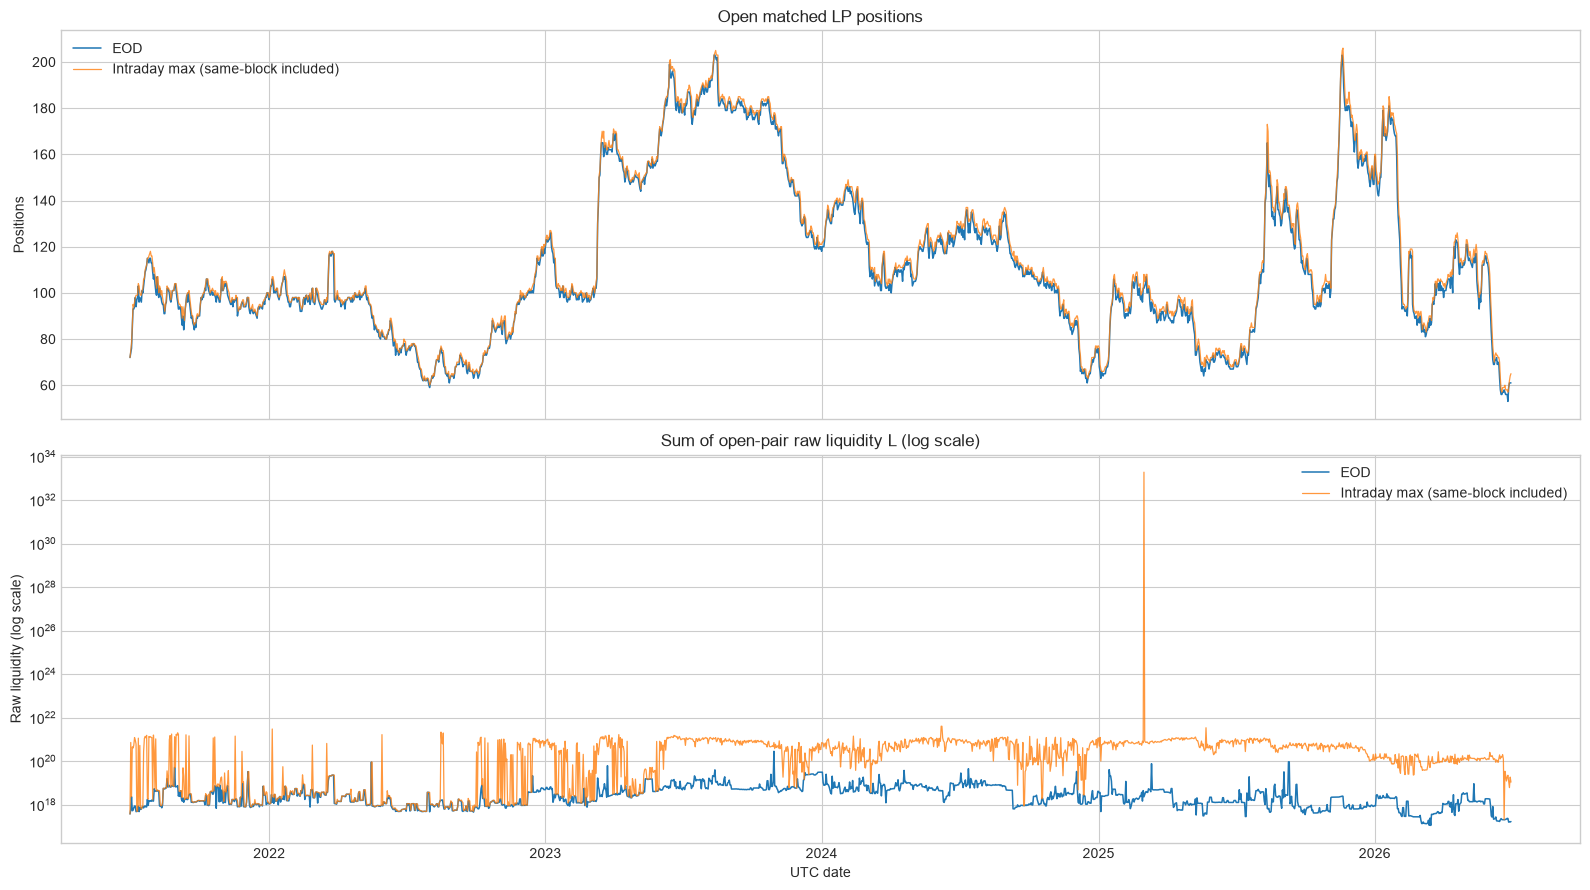

In [4]:
entries = pair_population[[
    'entry_block_timestamp', 'entry_block_number', 'entry_transaction_index', 'entry_log_index', 'liquidity_raw'
]].rename(columns={
    'entry_block_timestamp': 'timestamp', 'entry_block_number': 'block_number',
    'entry_transaction_index': 'transaction_index', 'entry_log_index': 'log_index'
})
entries = entries.assign(count_delta=1, liquidity_delta=entries['liquidity_raw'].map(int))
exits = pair_population[[
    'exit_block_timestamp', 'exit_block_number', 'exit_transaction_index', 'exit_log_index', 'liquidity_raw'
]].rename(columns={
    'exit_block_timestamp': 'timestamp', 'exit_block_number': 'block_number',
    'exit_transaction_index': 'transaction_index', 'exit_log_index': 'log_index'
})
exits = exits.assign(count_delta=-1, liquidity_delta=-exits['liquidity_raw'].map(int))
events = pd.concat([entries, exits], ignore_index=True).sort_values(
    ['block_number', 'transaction_index', 'log_index'], kind='stable'
)
events['active_positions'] = events['count_delta'].cumsum()
events['open_liquidity_raw'] = events['liquidity_delta'].cumsum()
events['date'] = pd.to_datetime(events['timestamp'], utc=True).dt.floor('D')
daily_index = pd.date_range(events['date'].min(), events['date'].max(), freq='D')
eod = events.groupby('date')[['active_positions', 'open_liquidity_raw']].last().reindex(daily_index).ffill().fillna(0)
peak = events.groupby('date')[['active_positions', 'open_liquidity_raw']].max().reindex(daily_index)
day_start = eod.shift(1).fillna(0)
peak = pd.DataFrame({
    'active_positions': pd.concat([peak['active_positions'], day_start['active_positions']], axis=1).max(axis=1),
    'open_liquidity_raw': pd.concat([peak['open_liquidity_raw'], day_start['open_liquidity_raw']], axis=1).max(axis=1),
})
plot_dates = (eod.index >= ANALYSIS_START) & (eod.index < ANALYSIS_END)
eod = eod.loc[plot_dates]
peak = peak.loc[plot_dates]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].plot(eod.index, eod['active_positions'], label='EOD', linewidth=1.1)
axes[0].plot(peak.index, peak['active_positions'], label='Intraday max (same-block included)', linewidth=0.9, alpha=0.8)
axes[0].set(title='Open matched LP positions', ylabel='Positions')
axes[0].legend()
eod_liquidity = eod['open_liquidity_raw'].astype(float).where(lambda values: values > 0)
peak_liquidity = peak['open_liquidity_raw'].astype(float).where(lambda values: values > 0)
axes[1].plot(eod.index, eod_liquidity, label='EOD', linewidth=1.1)
axes[1].plot(peak.index, peak_liquidity, label='Intraday max (same-block included)', linewidth=0.9, alpha=0.8)
axes[1].set_yscale('log')
axes[1].set(title='Sum of open-pair raw liquidity L (log scale)', ylabel='Raw liquidity (log scale)', xlabel='UTC date')
axes[1].legend()
plt.tight_layout(); plt.show()

## 4. Lifetime, size, realized fee, realized return 분포

Position size는 entry token amounts를 strict-prior ETHUSDT로 평가한 `initial_wealth_usdt`를 주지표로 사용한다. Daily return은 짧은 보유기간에서 기하 일환산값이 폭발할 수 있으므로 안정적인 continuously compounded daily log return을 주 분포로 보고, 기하·단순 일환산 quantile도 함께 제시한다. 그래프의 1–99% 확대는 가독성용이며 관측치를 삭제하지 않는다.

,fee_observation,count,share_pct
0,All observed-fee analysis positions,10158,100
1,Exit Collect observed,10060,99.0352
2,Exit Collect not observed,98,0.964757


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
initial_wealth_usdt,"10,158","464,580",2.24662e+06,2.06165e-06,9.99484,95.2237,"2,880.4","28,661.7","151,235",1.68795e+06,1.01261e+07,8.24488e+07
realized_fee_value_usdt,"10,158","3,321.14","23,819.3",0,0,0,5.26808,103.069,779.572,"9,258.61","64,394.2",1.01745e+06
fee_return_on_initial_wealth,"10,158",0.0168913,0.0401762,0,0,0,0.000840794,0.00556973,0.0170494,0.0686634,0.158052,1.19282
lp_total_return_realized_fee,"10,158",-0.00167469,0.0838225,-0.684158,-0.284611,-0.121233,-0.0126352,0.000851289,0.0182232,0.0883664,0.24904,1.31161
holding_days,"10,158",17.1819,69.691,0.000138889,0.00112431,0.00777778,0.351285,1.91101,8.46767,75.1587,274.453,"1,806.05"
realized_daily_log_return,"10,158",-0.0839859,7.46937,-751.563,-0.478862,-0.0971173,-0.0070278,0.000844411,0.00683528,0.0512705,0.254861,15.2835
realized_daily_return_geometric,"10,158",427.429,"43,065.4",-1,-0.380499,-0.0925504,-0.00700317,0.000844767,0.0068587,0.0526076,0.290282,4.34043e+06
realized_daily_return_simple,"10,158",-0.064561,5.55826,-558.522,-0.474988,-0.0954158,-0.00688444,0.000871868,0.00694545,0.0516042,0.256282,15.414


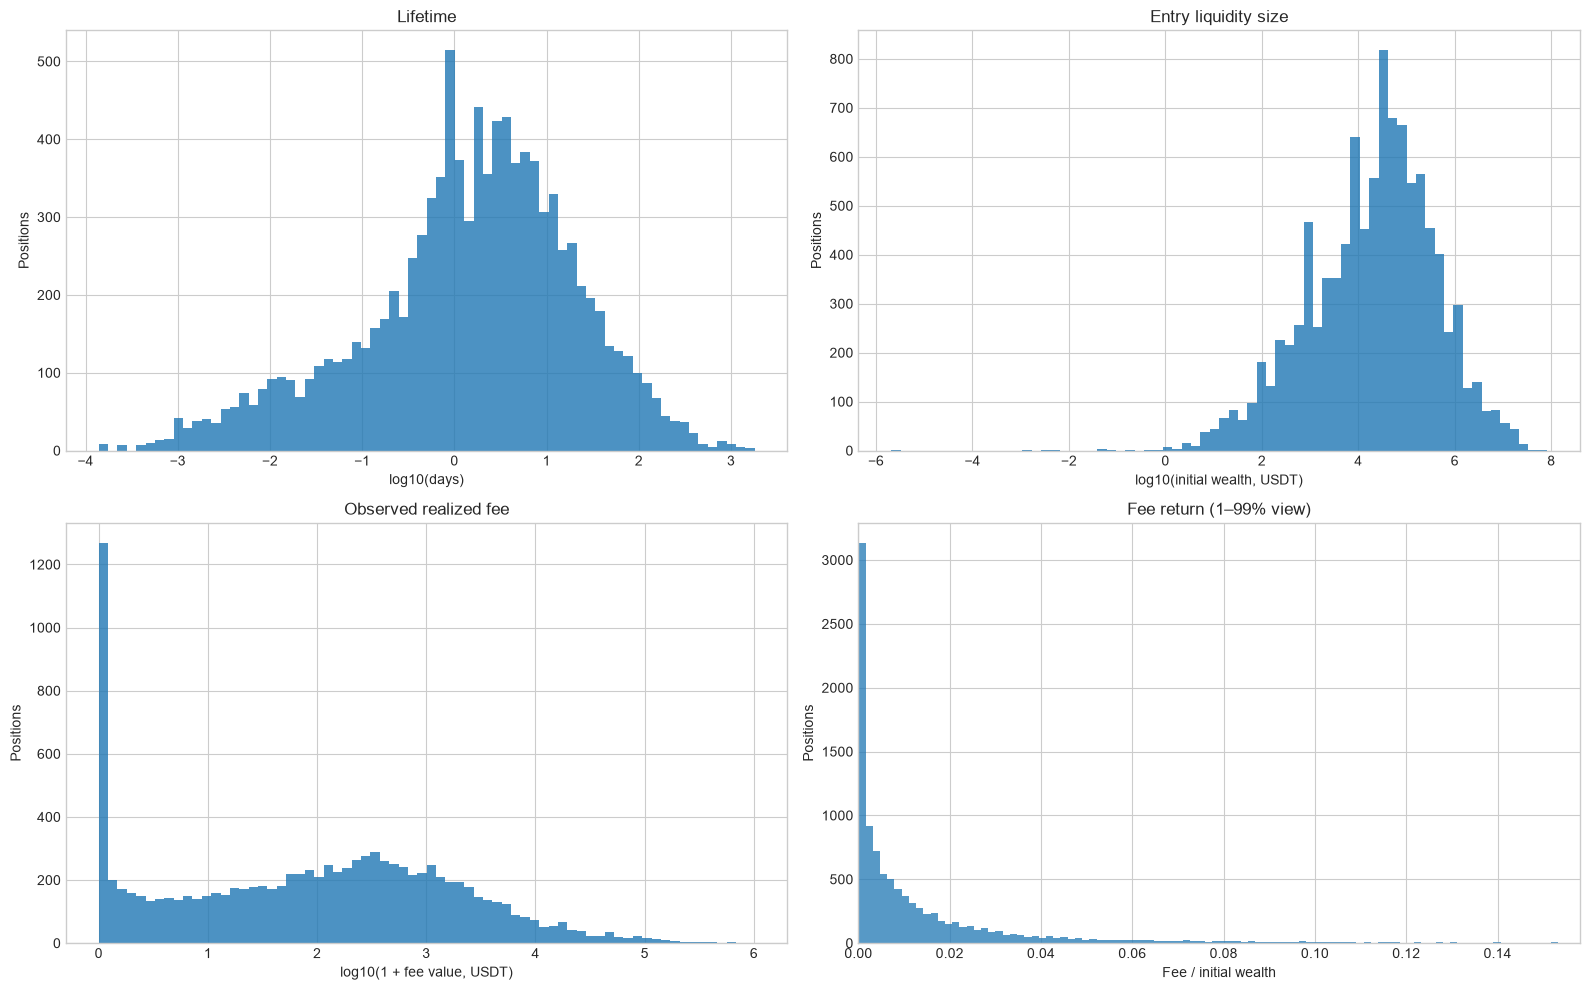

In [5]:
numeric_columns = [
    'initial_wealth_usdt', 'realized_fee_value_usdt', 'fee_return_on_initial_wealth',
    'lp_total_return_realized_fee', 'holding_days', 'realized_daily_log_return',
    'realized_daily_return_geometric', 'realized_daily_return_simple'
]
for column in numeric_columns:
    analysis_returns[column] = pd.to_numeric(analysis_returns[column])
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
distribution_summary = analysis_returns[numeric_columns].describe(percentiles=quantiles).T
fee_observation_counts = pd.DataFrame([
    ('All observed-fee analysis positions', len(analysis_returns)),
    ('Exit Collect observed', int(analysis_returns['exit_collect_observed'].sum())),
    ('Exit Collect not observed', int((~analysis_returns['exit_collect_observed']).sum())),
], columns=['fee_observation', 'count'])
fee_observation_counts['share_pct'] = 100 * fee_observation_counts['count'] / len(analysis_returns)
display(fee_observation_counts, distribution_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].hist(np.log10(analysis_returns['holding_days']), bins=70, alpha=0.8)
axes[0, 0].set(title='Lifetime', xlabel='log10(days)', ylabel='Positions')
axes[0, 1].hist(np.log10(analysis_returns['initial_wealth_usdt']), bins=70, alpha=0.8)
axes[0, 1].set(title='Entry liquidity size', xlabel='log10(initial wealth, USDT)', ylabel='Positions')
axes[1, 0].hist(np.log10(1 + analysis_returns['realized_fee_value_usdt']), bins=70, alpha=0.8)
axes[1, 0].set(title='Observed realized fee', xlabel='log10(1 + fee value, USDT)', ylabel='Positions')
fee_lo, fee_hi = analysis_returns['fee_return_on_initial_wealth'].quantile([0.01, 0.99])
axes[1, 1].hist(analysis_returns['fee_return_on_initial_wealth'], bins=100, range=(fee_lo, fee_hi), alpha=0.75)
axes[1, 1].set(xlim=(fee_lo, fee_hi), title='Fee return (1–99% view)', xlabel='Fee / initial wealth', ylabel='Positions')
plt.tight_layout(); plt.show()

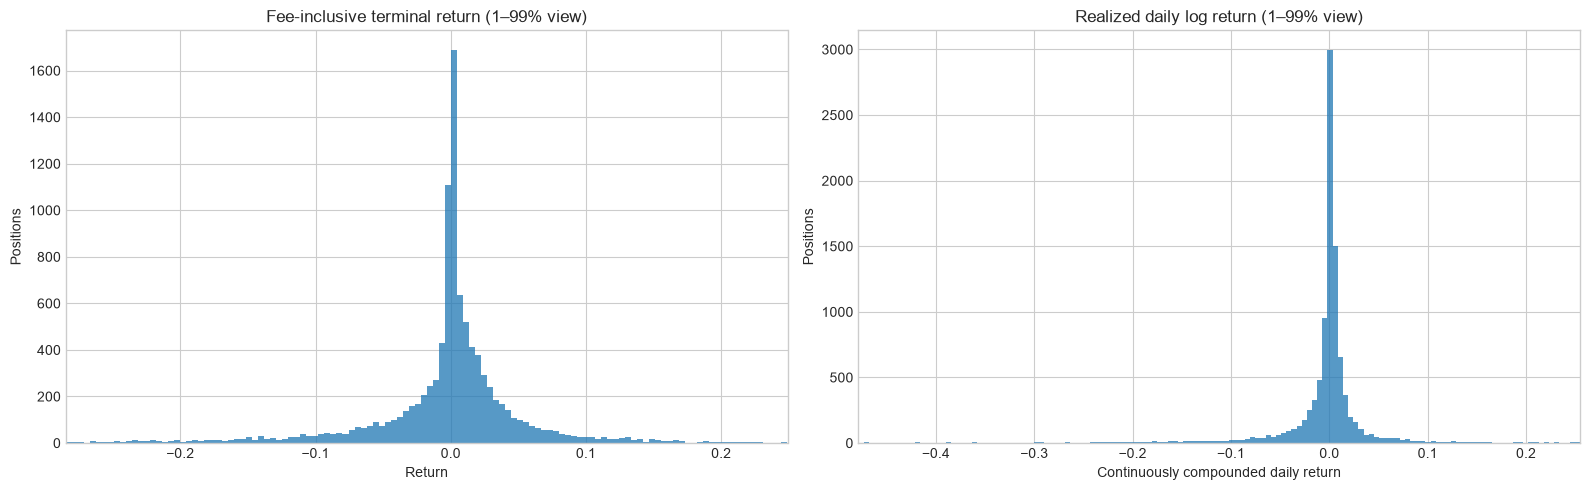

,metric,min,p01,median,p99,max
0,terminal return,-0.684158,-0.284611,0.000851289,0.24904,1.31161
1,daily log return,-751.563,-0.478862,0.000844411,0.254861,15.2835
2,daily geometric return,-1,-0.380499,0.000844767,0.290282,4.34043e+06
3,daily simple return,-558.522,-0.474988,0.000871868,0.256282,15.414


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
terminal = analysis_returns['lp_total_return_realized_fee']
lo, hi = terminal.quantile([0.01, 0.99])
axes[0].hist(terminal, bins=120, range=(lo, hi), alpha=0.75)
axes[0].set(xlim=(lo, hi), title='Fee-inclusive terminal return (1–99% view)', xlabel='Return', ylabel='Positions')
daily = analysis_returns['realized_daily_log_return']
lo, hi = daily.quantile([0.01, 0.99])
axes[1].hist(daily, bins=140, range=(lo, hi), alpha=0.75)
axes[1].set(xlim=(lo, hi), title='Realized daily log return (1–99% view)', xlabel='Continuously compounded daily return', ylabel='Positions')
plt.tight_layout(); plt.show()

tail_table = pd.DataFrame({
    'metric': ['terminal return', 'daily log return', 'daily geometric return', 'daily simple return'],
    'min': [analysis_returns[c].replace([np.inf, -np.inf], np.nan).min() for c in ['lp_total_return_realized_fee', 'realized_daily_log_return', 'realized_daily_return_geometric', 'realized_daily_return_simple']],
    'p01': [analysis_returns[c].replace([np.inf, -np.inf], np.nan).quantile(.01) for c in ['lp_total_return_realized_fee', 'realized_daily_log_return', 'realized_daily_return_geometric', 'realized_daily_return_simple']],
    'median': [analysis_returns[c].replace([np.inf, -np.inf], np.nan).median() for c in ['lp_total_return_realized_fee', 'realized_daily_log_return', 'realized_daily_return_geometric', 'realized_daily_return_simple']],
    'p99': [analysis_returns[c].replace([np.inf, -np.inf], np.nan).quantile(.99) for c in ['lp_total_return_realized_fee', 'realized_daily_log_return', 'realized_daily_return_geometric', 'realized_daily_return_simple']],
    'max': [analysis_returns[c].replace([np.inf, -np.inf], np.nan).max() for c in ['lp_total_return_realized_fee', 'realized_daily_log_return', 'realized_daily_return_geometric', 'realized_daily_return_simple']],
})
display(tail_table)

## 5. Position size와 lifetime의 관계

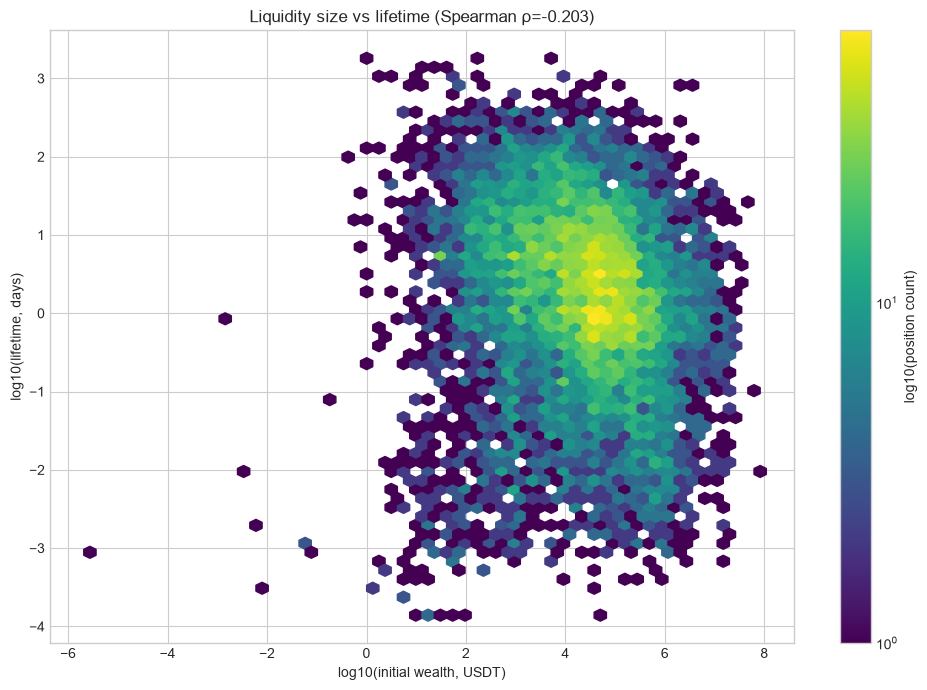

In [7]:
x = np.log10(analysis_returns['initial_wealth_usdt'])
y = np.log10(analysis_returns['holding_days'])
spearman = x.rank().corr(y.rank())
fig, ax = plt.subplots(figsize=(10, 7))
plot = ax.hexbin(x, y, gridsize=55, mincnt=1, bins='log', cmap='viridis')
fig.colorbar(plot, ax=ax, label='log10(position count)')
ax.set(title=f'Liquidity size vs lifetime (Spearman ρ={spearman:.3f})', xlabel='log10(initial wealth, USDT)', ylabel='log10(lifetime, days)')
plt.tight_layout(); plt.show()

## 6. Lifetime·size와 realized daily return의 관계

Position-level `realized_daily_log_return`을 lifetime과 entry wealth에 각각 대응시킨다. Lifetime과 wealth는 범위가 매우 넓어 x축만 로그축으로 표시한다. Spearman 상관계수는 전체 10,158개 관측치로 계산하고, 산점도의 y축만 daily return의 1–99% 범위로 확대하므로 tail 관측치를 통계 계산에서 삭제하지 않는다.

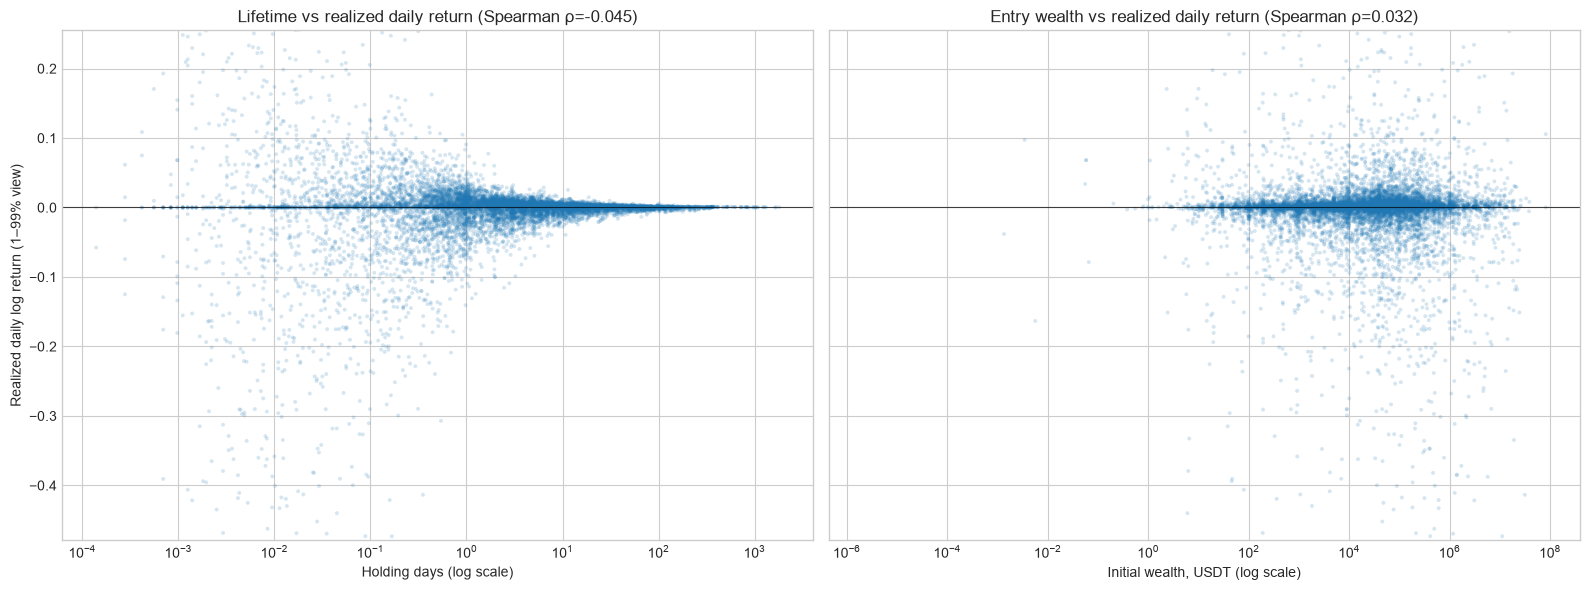

In [8]:
lifetime = analysis_returns['holding_days']
wealth = analysis_returns['initial_wealth_usdt']
daily_return = analysis_returns['realized_daily_log_return']
lifetime_return_spearman = lifetime.rank().corr(daily_return.rank())
wealth_return_spearman = wealth.rank().corr(daily_return.rank())
return_lo, return_hi = daily_return.quantile([0.01, 0.99])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
axes[0].scatter(lifetime, daily_return, s=8, alpha=0.18, edgecolors='none')
axes[0].set_xscale('log')
axes[0].set(ylim=(return_lo, return_hi), title=f'Lifetime vs realized daily return (Spearman ρ={lifetime_return_spearman:.3f})', xlabel='Holding days (log scale)', ylabel='Realized daily log return (1–99% view)')
axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.7)
axes[1].scatter(wealth, daily_return, s=8, alpha=0.18, edgecolors='none')
axes[1].set_xscale('log')
axes[1].set(ylim=(return_lo, return_hi), title=f'Entry wealth vs realized daily return (Spearman ρ={wealth_return_spearman:.3f})', xlabel='Initial wealth, USDT (log scale)')
axes[1].axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.tight_layout(); plt.show()

## 7. Lifetime과 liquidity size의 daily time series

각 UTC 날짜에 진입한 fully observed multi-block position cohort별로 mean과 median을 계산한다. 두 변수 모두 오른쪽 꼬리가 길어 로그축을 사용하며, 일별 표본 수가 적은 날에는 mean과 median의 변동성이 클 수 있다. 원계열과 함께 달력 기준 30일 동안의 일별 통계 이동평균을 표시한다.

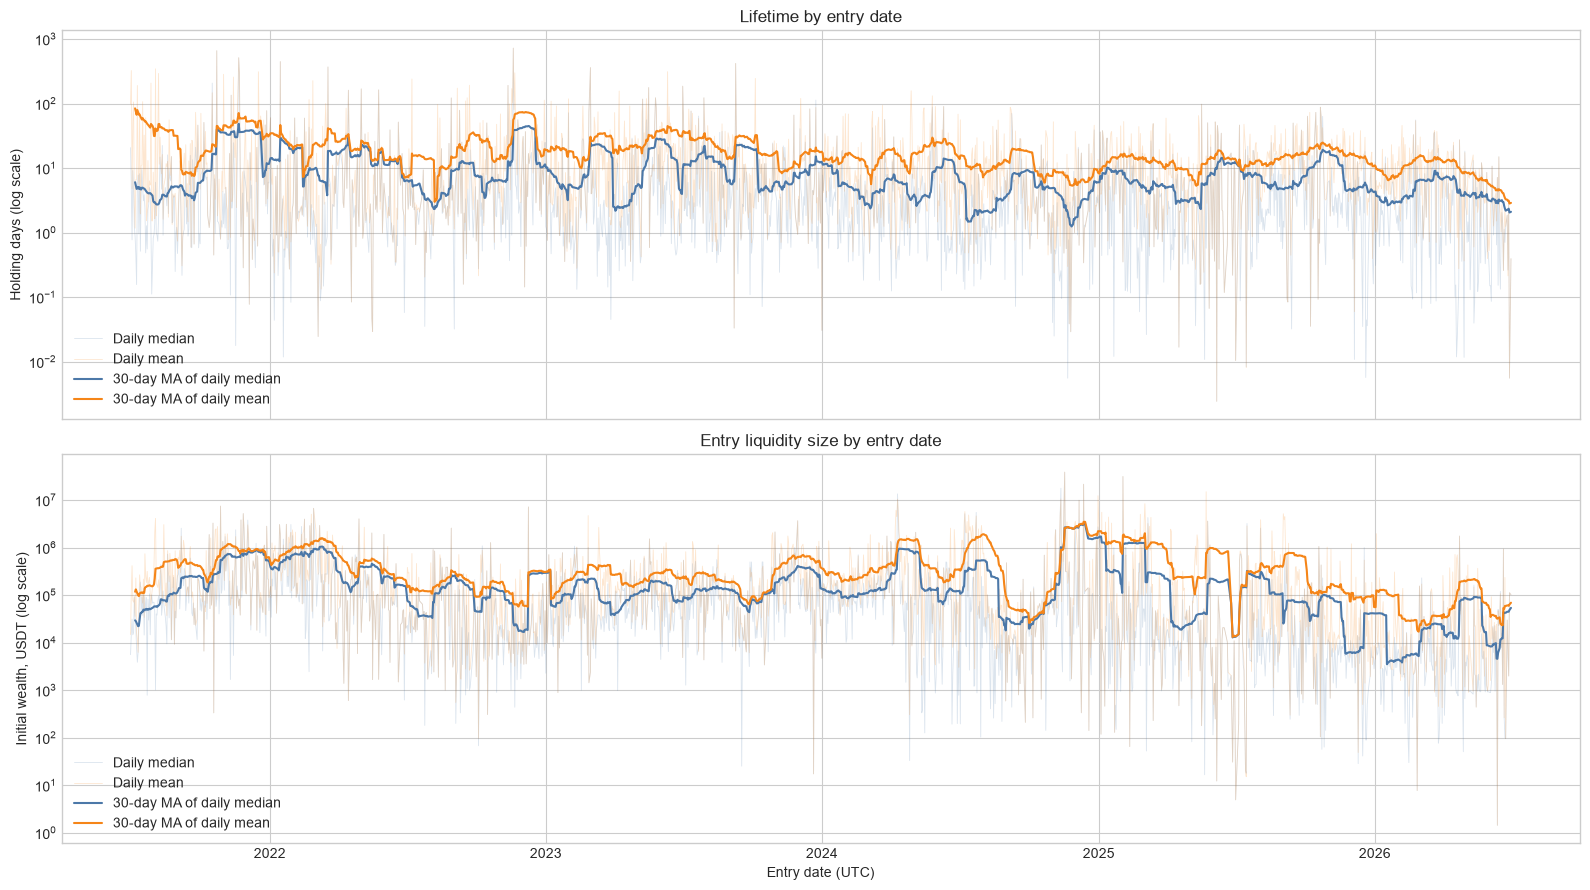

,count,mean,std,min,25%,50%,75%,max
position_count,"1,705",5.95777,5.4747,1,3,5,7,61
lifetime_median_days,"1,705",9.6025,37.5079,0.00243056,0.911875,2.51389,6.35069,723.145
lifetime_mean_days,"1,705",19.4822,46.3043,0.00243056,2.62829,7.02426,17.3966,723.145
size_median_usdt,"1,705","271,622",1.55879e+06,1.43554,"7,622.89","36,605.1","120,776",3.87499e+07
size_mean_usdt,"1,705","482,640",1.67367e+06,1.43554,"21,533.7","100,512","316,886",3.87499e+07


In [9]:
analysis_returns['entry_date'] = pd.to_datetime(analysis_returns['entry_timestamp'], utc=True).dt.floor('D')
daily_position_metrics = analysis_returns.groupby('entry_date').agg(
    position_count=('operation_id', 'size'),
    lifetime_median_days=('holding_days', 'median'),
    lifetime_mean_days=('holding_days', 'mean'),
    size_median_usdt=('initial_wealth_usdt', 'median'),
    size_mean_usdt=('initial_wealth_usdt', 'mean'),
).reset_index().sort_values('entry_date')
metric_columns = ['lifetime_median_days', 'lifetime_mean_days', 'size_median_usdt', 'size_mean_usdt']
rolling_position_metrics = daily_position_metrics.set_index('entry_date')[metric_columns].rolling('30D', min_periods=7).mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].plot(daily_position_metrics['entry_date'], daily_position_metrics['lifetime_median_days'], color='#4C78A8', label='Daily median', linewidth=0.6, alpha=0.2)
axes[0].plot(daily_position_metrics['entry_date'], daily_position_metrics['lifetime_mean_days'], color='#F58518', label='Daily mean', linewidth=0.6, alpha=0.2)
axes[0].plot(rolling_position_metrics['entry_date'], rolling_position_metrics['lifetime_median_days'], color='#4C78A8', label='30-day MA of daily median', linewidth=1.5)
axes[0].plot(rolling_position_metrics['entry_date'], rolling_position_metrics['lifetime_mean_days'], color='#F58518', label='30-day MA of daily mean', linewidth=1.5)
axes[0].set_yscale('log')
axes[0].set(title='Lifetime by entry date', ylabel='Holding days (log scale)')
axes[0].legend()
axes[1].plot(daily_position_metrics['entry_date'], daily_position_metrics['size_median_usdt'], color='#4C78A8', label='Daily median', linewidth=0.6, alpha=0.2)
axes[1].plot(daily_position_metrics['entry_date'], daily_position_metrics['size_mean_usdt'], color='#F58518', label='Daily mean', linewidth=0.6, alpha=0.2)
axes[1].plot(rolling_position_metrics['entry_date'], rolling_position_metrics['size_median_usdt'], color='#4C78A8', label='30-day MA of daily median', linewidth=1.5)
axes[1].plot(rolling_position_metrics['entry_date'], rolling_position_metrics['size_mean_usdt'], color='#F58518', label='30-day MA of daily mean', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set(title='Entry liquidity size by entry date', ylabel='Initial wealth, USDT (log scale)', xlabel='Entry date (UTC)')
axes[1].legend()
plt.tight_layout(); plt.show()
display(daily_position_metrics.describe().T)

## 8. Swap count와 volume time series

Daily swap volume은 `abs(amount1)`의 합, 즉 quote token인 USDT leg의 절대량이다. WETH와 USDT 양쪽 leg를 더해 거래를 이중계산하지 않는다. 일별 원계열과 30일 이동평균을 함께 표시한다.

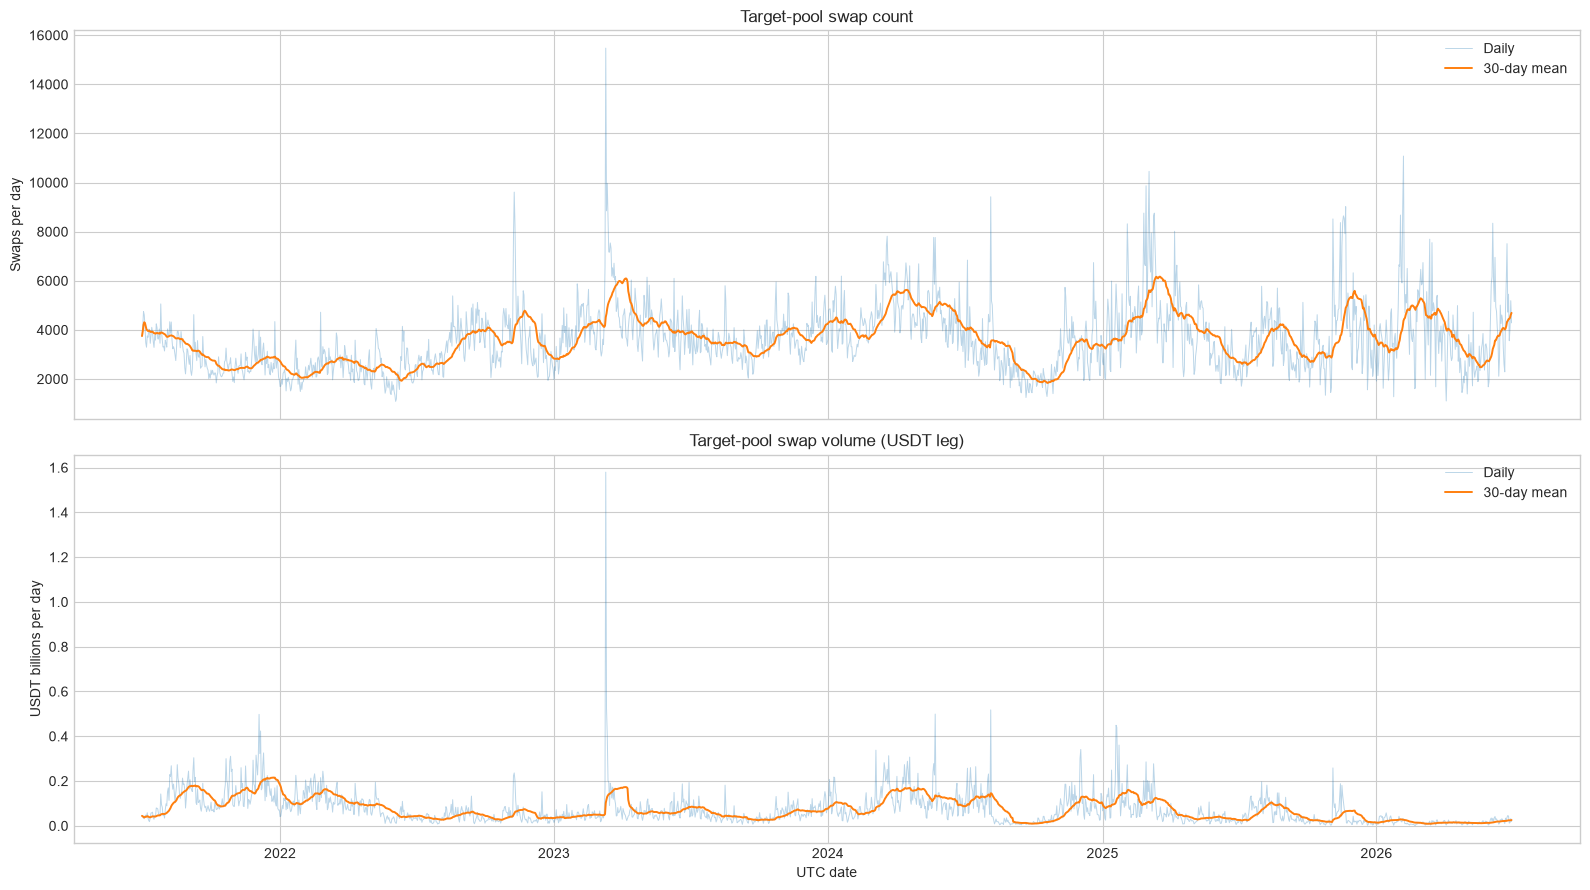

In [10]:
pool_daily = pd.read_parquet(POOL_DAILY_PATH)
pool_daily['date'] = pd.to_datetime(pool_daily['date'], utc=True)
pool_daily = pool_daily.loc[(pool_daily['date'] >= ANALYSIS_START) & (pool_daily['date'] < ANALYSIS_END)].copy()
pool_daily['swap_volume_usdt'] = pd.to_numeric(pool_daily['swap_abs_amount1_raw']) / 1e6
pool_daily['swap_count_30d_mean'] = pool_daily['swap_count'].rolling(30, min_periods=1).mean()
pool_daily['swap_volume_30d_mean_usdt'] = pool_daily['swap_volume_usdt'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].plot(pool_daily['date'], pool_daily['swap_count'], alpha=0.3, linewidth=0.7, label='Daily')
axes[0].plot(pool_daily['date'], pool_daily['swap_count_30d_mean'], linewidth=1.4, label='30-day mean')
axes[0].set(title='Target-pool swap count', ylabel='Swaps per day')
axes[0].legend()
axes[1].plot(pool_daily['date'], pool_daily['swap_volume_usdt'] / 1e9, alpha=0.3, linewidth=0.7, label='Daily')
axes[1].plot(pool_daily['date'], pool_daily['swap_volume_30d_mean_usdt'] / 1e9, linewidth=1.4, label='30-day mean')
axes[1].set(title='Target-pool swap volume (USDT leg)', ylabel='USDT billions per day', xlabel='UTC date')
axes[1].legend()
plt.tight_layout(); plt.show()

## 9. ETHUSDT price, historical volatility, realized volatility

1초 Oracle을 월별로 읽어 UTC 일별 마지막 close와 10분 close를 만든다. Historical volatility는 일별 log return의 30일 rolling sample standard deviation에 $\sqrt{365}$를 곱한 연율이다. Daily realized volatility는 10분 log return의 일별 제곱합 제곱근이며, 비교 가능한 차트에는 다시 $\sqrt{365}$를 곱한 연율 값을 표시한다.

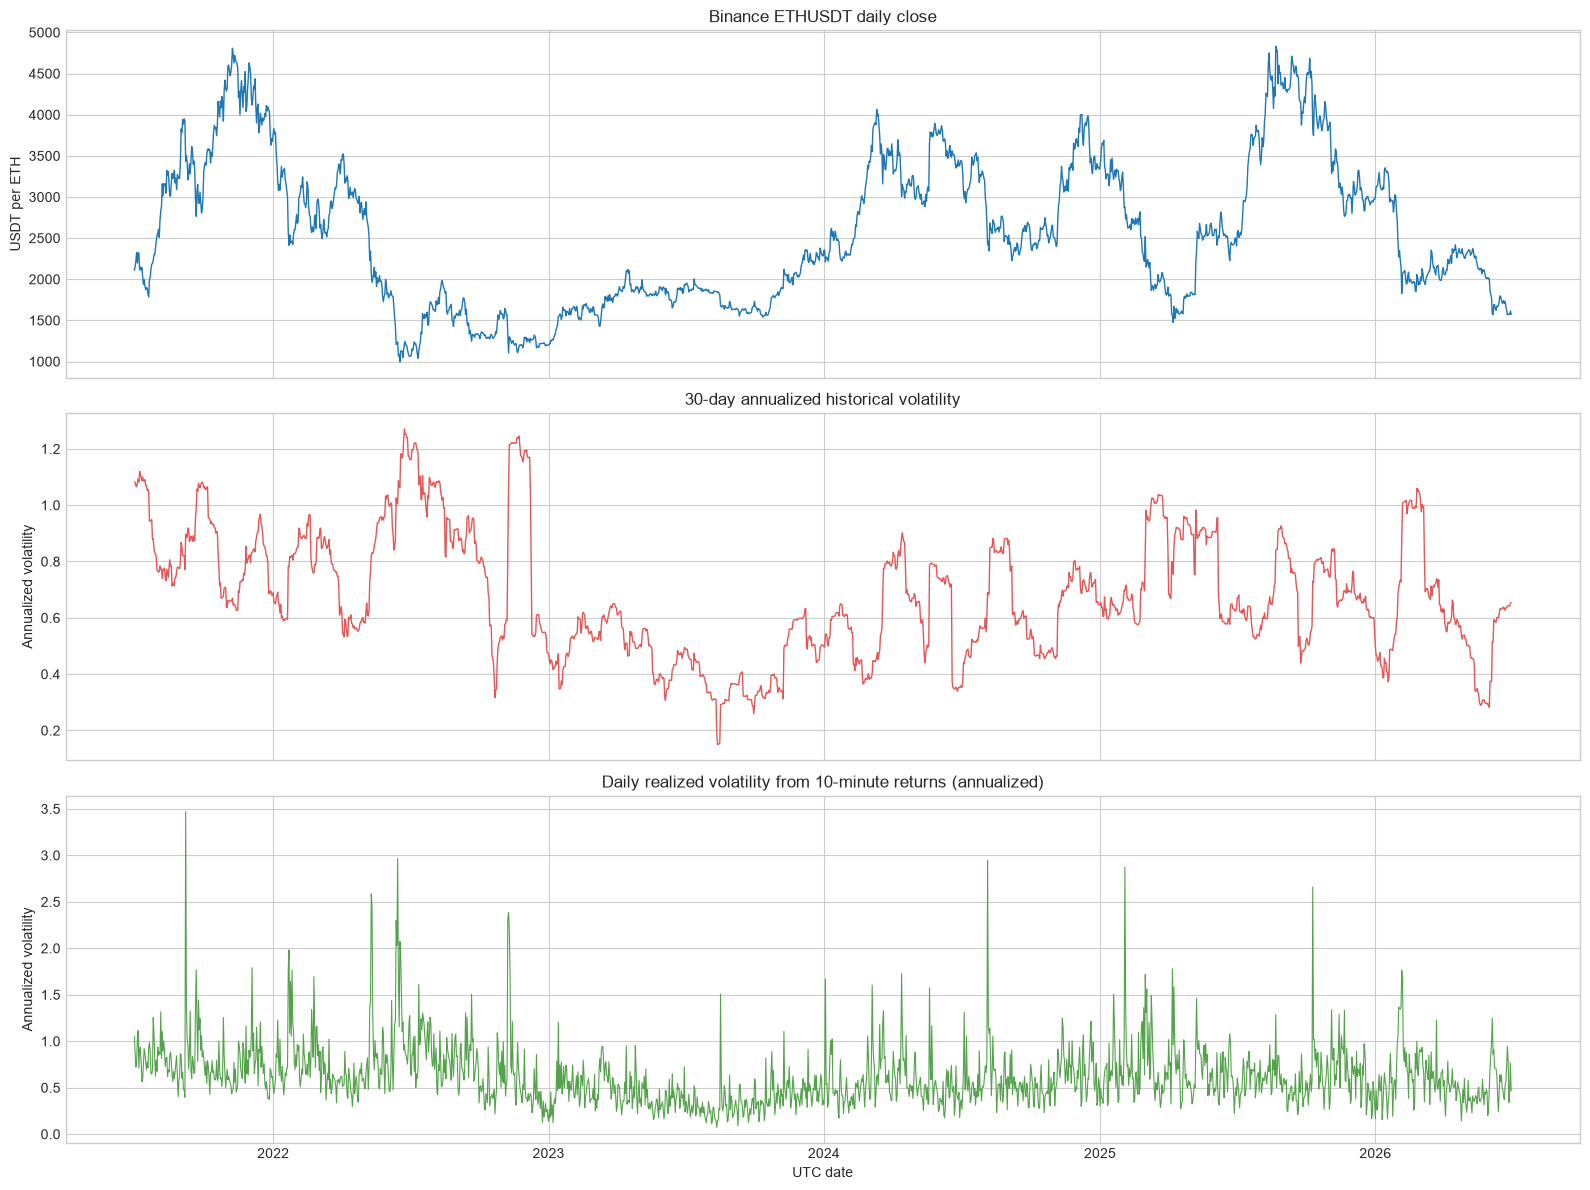

In [11]:
daily_parts = []
ten_minute_parts = []
for path in sorted(ORACLE_ROOT.glob('weth_usdt_1s_*.parquet')):
    month = pq.read_table(path, columns=['timestamp', 'price']).to_pandas()
    month['date'] = month['timestamp'].dt.floor('D')
    daily_parts.append(month.groupby('date', as_index=False).last()[['date', 'price']])
    ten_minute_parts.append(month.set_index('timestamp')['price'].resample('10min').last().rename('price').reset_index())
eth_daily = pd.concat(daily_parts, ignore_index=True).drop_duplicates('date', keep='last').sort_values('date')
eth_daily['log_return'] = np.log(eth_daily['price']).diff()
eth_daily['historical_volatility_30d'] = eth_daily['log_return'].rolling(30, min_periods=30).std(ddof=1) * np.sqrt(365)
eth_10min = pd.concat(ten_minute_parts, ignore_index=True).drop_duplicates('timestamp', keep='last').sort_values('timestamp')
eth_10min['log_return_10m'] = np.log(eth_10min['price']).diff()
eth_10min['date'] = eth_10min['timestamp'].dt.floor('D')
eth_10min['squared_log_return_10m'] = eth_10min['log_return_10m'].pow(2)
daily_realized = np.sqrt(eth_10min.groupby('date')['squared_log_return_10m'].sum(min_count=1)).rename('realized_volatility_daily')
eth_daily = eth_daily.merge(daily_realized, on='date', how='left')
eth_daily['realized_volatility_10m_annualized'] = eth_daily['realized_volatility_daily'] * np.sqrt(365)
market_daily = eth_daily.loc[(eth_daily['date'] >= ANALYSIS_START) & (eth_daily['date'] < ANALYSIS_END)].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
axes[0].plot(market_daily['date'], market_daily['price'], linewidth=1.0)
axes[0].set(title='Binance ETHUSDT daily close', ylabel='USDT per ETH')
axes[1].plot(market_daily['date'], market_daily['historical_volatility_30d'], color='#E45756', linewidth=1.0)
axes[1].set(title='30-day annualized historical volatility', ylabel='Annualized volatility')
axes[2].plot(market_daily['date'], market_daily['realized_volatility_10m_annualized'], color='#54A24B', linewidth=0.8)
axes[2].set(title='Daily realized volatility from 10-minute returns (annualized)', ylabel='Annualized volatility', xlabel='UTC date')
plt.tight_layout(); plt.show()

## 10. Volatility와 position activity의 관계

각 UTC 날짜의 volatility를 EOD active matched-position count, pool swap count, same-block pair count와 차례로 결합한다. Same-block pair는 EOD에 남지 않으므로 entry date별 발생 건수를 사용한다. 상관계수는 전체 일자를 사용하고 산점도의 volatility x축만 1–99%로 확대한다. 날짜별 관측치는 강한 시계열 의존성을 가지므로 독립표본 p-value나 인과효과로 해석하지 않는다.

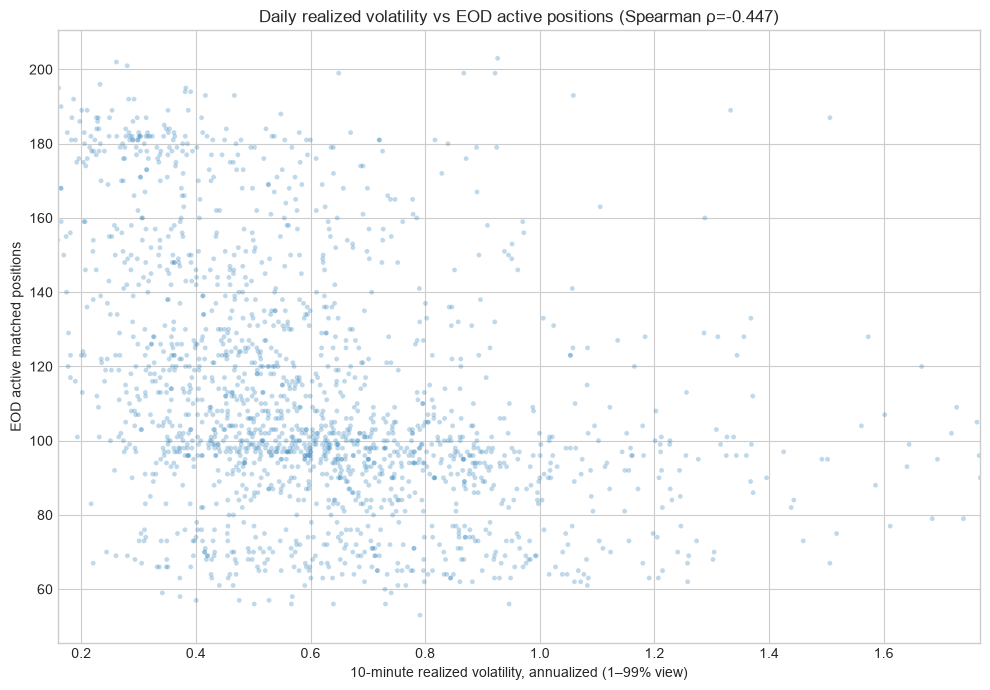

In [12]:
active_daily = eod[['active_positions']].rename_axis('date').reset_index()
volatility_position = market_daily[['date', 'realized_volatility_10m_annualized']].merge(active_daily, on='date', how='inner').dropna()
volatility_count_spearman = volatility_position['realized_volatility_10m_annualized'].rank().corr(volatility_position['active_positions'].rank())
vol_lo, vol_hi = volatility_position['realized_volatility_10m_annualized'].quantile([0.01, 0.99])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(volatility_position['realized_volatility_10m_annualized'], volatility_position['active_positions'], s=12, alpha=0.28, edgecolors='none')
ax.set(xlim=(vol_lo, vol_hi), title=f'Daily realized volatility vs EOD active positions (Spearman ρ={volatility_count_spearman:.3f})', xlabel='10-minute realized volatility, annualized (1–99% view)', ylabel='EOD active matched positions')
plt.tight_layout(); plt.show()

### Swap count와 volatility

분석기간의 일별 target-pool swap count를 같은 날짜의 10분 realized volatility와 30일 historical volatility에 각각 대응시킨다.

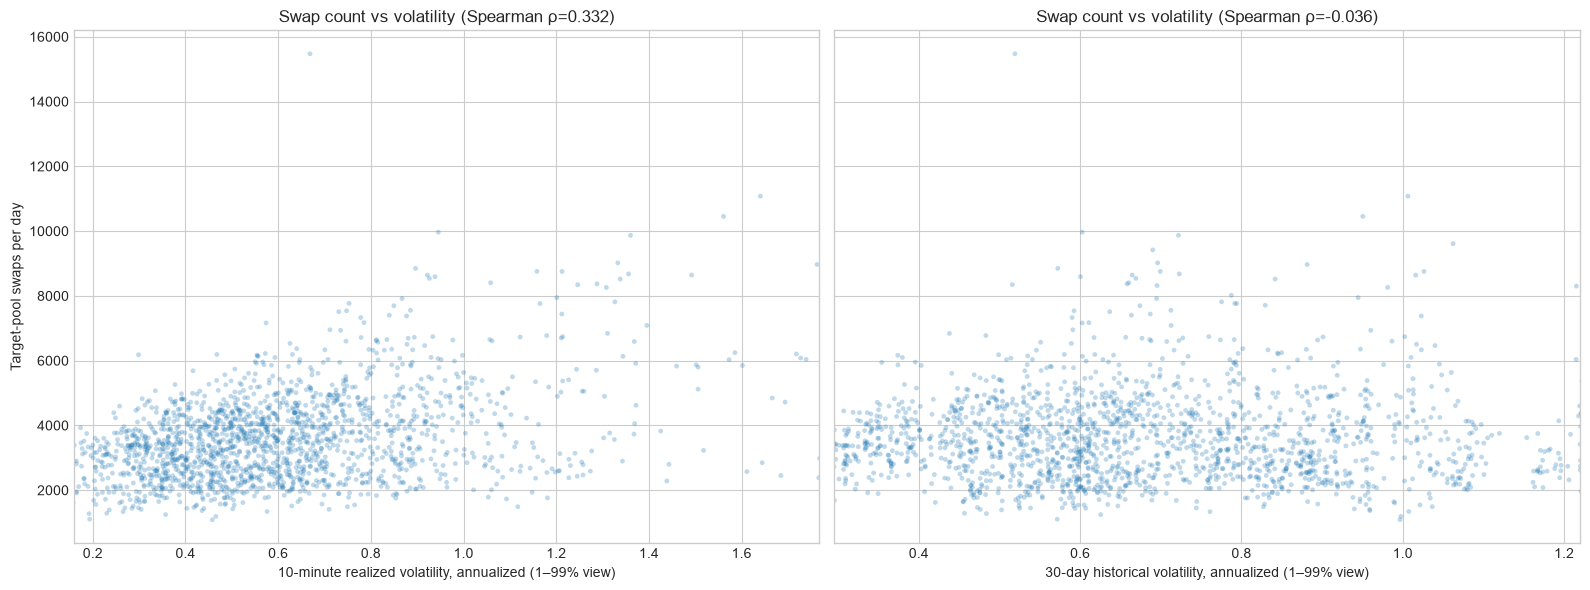

In [13]:
swap_volatility = market_daily[['date', 'realized_volatility_10m_annualized', 'historical_volatility_30d']].merge(
    pool_daily[['date', 'swap_count']], on='date', how='inner'
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, column, label in [
    (axes[0], 'realized_volatility_10m_annualized', '10-minute realized volatility, annualized'),
    (axes[1], 'historical_volatility_30d', '30-day historical volatility, annualized'),
]:
    rho = swap_volatility['swap_count'].rank().corr(swap_volatility[column].rank())
    lo, hi = swap_volatility[column].quantile([0.01, 0.99])
    ax.scatter(swap_volatility[column], swap_volatility['swap_count'], s=12, alpha=0.28, edgecolors='none')
    ax.set(xlim=(lo, hi), title=f'Swap count vs volatility (Spearman ρ={rho:.3f})', xlabel=f'{label} (1–99% view)')
axes[0].set_ylabel('Target-pool swaps per day')
plt.tight_layout(); plt.show()

### Same-block pair count와 volatility

Same-block position은 EOD active count에 남지 않으므로, 해당 날짜에 진입·청산된 pair 수를 activity 변수로 사용한다. 전체 날짜의 발생 여부·건수를 보는 extensive margin과, 한 건 이상 발생한 날에 건수가 얼마나 늘어나는지를 보는 intensive margin을 분리한다. 일별 noise 및 자기상관에 덜 민감한 주별 합계–주별 평균 관계도 표로 비교한다.

,sample,volatility_measure,observations,spearman_rho
0,Daily: all days,10-minute realized volatility,1826,-0.0982169
1,Daily: all days,30-day historical volatility,1826,-0.143996
2,Daily: count > 0,10-minute realized volatility,1296,0.248099
3,Daily: count > 0,30-day historical volatility,1296,0.298507
4,Weekly: all weeks,Mean 10-minute realized volatility,262,-0.161886
5,Weekly: all weeks,Mean 30-day historical volatility,262,-0.170073


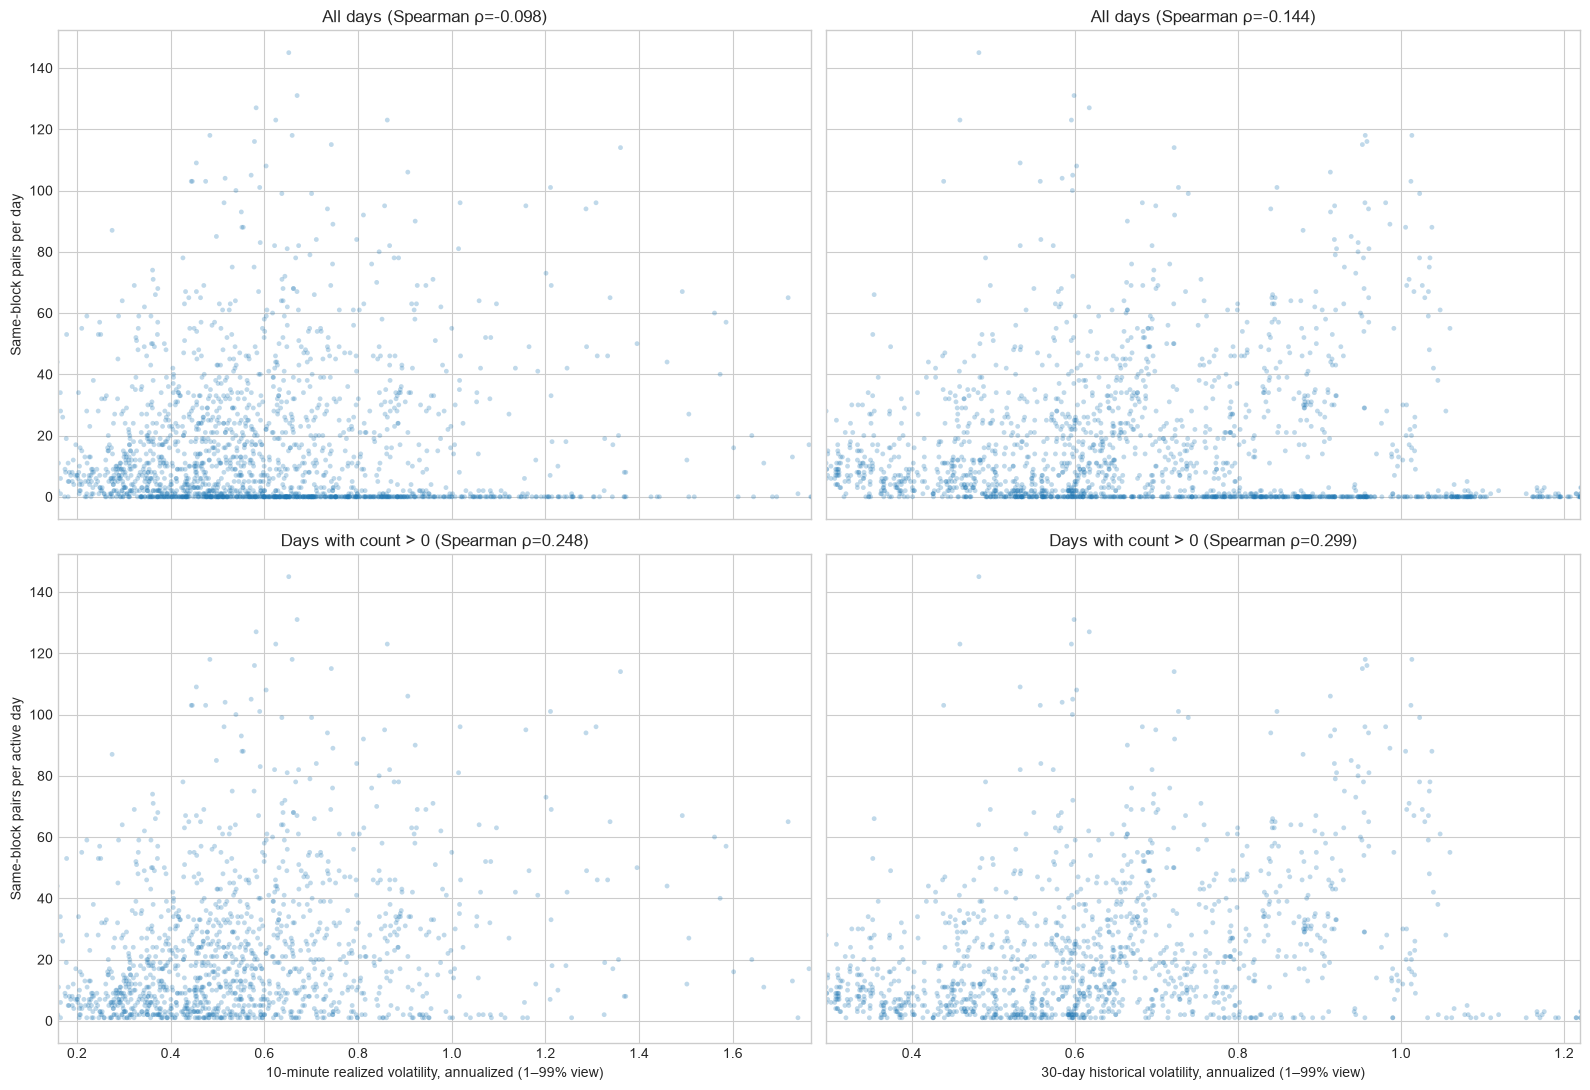

In [14]:
same_block_pairs = window_pairs.loc[window_pairs['is_same_block']].copy()
same_block_pairs['date'] = pd.to_datetime(same_block_pairs['entry_block_timestamp'], utc=True).dt.floor('D')
same_block_count = same_block_pairs.groupby('date').size().rename('same_block_count').reset_index()
same_block_volatility = market_daily[['date', 'realized_volatility_10m_annualized', 'historical_volatility_30d']].merge(same_block_count, on='date', how='left')
same_block_volatility['same_block_count'] = same_block_volatility['same_block_count'].fillna(0).astype(int)
weekly_same_block_volatility = same_block_volatility.set_index('date').resample('W-SUN').agg(
    same_block_count=('same_block_count', 'sum'),
    realized_volatility_10m_annualized=('realized_volatility_10m_annualized', 'mean'),
    historical_volatility_30d=('historical_volatility_30d', 'mean'),
).dropna()

def rank_correlation(frame, volatility_column):
    return frame['same_block_count'].rank().corr(frame[volatility_column].rank())

active_same_block_days = same_block_volatility.loc[same_block_volatility['same_block_count'] > 0].copy()
same_block_correlation = pd.DataFrame([
    ('Daily: all days', '10-minute realized volatility', len(same_block_volatility), rank_correlation(same_block_volatility, 'realized_volatility_10m_annualized')),
    ('Daily: all days', '30-day historical volatility', len(same_block_volatility), rank_correlation(same_block_volatility, 'historical_volatility_30d')),
    ('Daily: count > 0', '10-minute realized volatility', len(active_same_block_days), rank_correlation(active_same_block_days, 'realized_volatility_10m_annualized')),
    ('Daily: count > 0', '30-day historical volatility', len(active_same_block_days), rank_correlation(active_same_block_days, 'historical_volatility_30d')),
    ('Weekly: all weeks', 'Mean 10-minute realized volatility', len(weekly_same_block_volatility), rank_correlation(weekly_same_block_volatility, 'realized_volatility_10m_annualized')),
    ('Weekly: all weeks', 'Mean 30-day historical volatility', len(weekly_same_block_volatility), rank_correlation(weekly_same_block_volatility, 'historical_volatility_30d')),
], columns=['sample', 'volatility_measure', 'observations', 'spearman_rho'])
display(same_block_correlation)

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex='col', sharey=True)
plot_specs = [
    ('realized_volatility_10m_annualized', '10-minute realized volatility, annualized'),
    ('historical_volatility_30d', '30-day historical volatility, annualized'),
]
for column_index, (column, label) in enumerate(plot_specs):
    lo, hi = same_block_volatility[column].quantile([0.01, 0.99])
    for row_index, (sample_label, frame) in enumerate([('All days', same_block_volatility), ('Days with count > 0', active_same_block_days)]):
        ax = axes[row_index, column_index]
        rho = rank_correlation(frame, column)
        ax.scatter(frame[column], frame['same_block_count'], s=12, alpha=0.28, edgecolors='none')
        ax.set(xlim=(lo, hi), title=f'{sample_label} (Spearman ρ={rho:.3f})')
        if row_index == 1:
            ax.set_xlabel(f'{label} (1–99% view)')
axes[0, 0].set_ylabel('Same-block pairs per day')
axes[1, 0].set_ylabel('Same-block pairs per active day')
plt.tight_layout(); plt.show()
assert same_block_volatility['same_block_count'].sum() == 30_101

### Same-block activity와 volatility의 time series

세 계열을 동일한 UTC 날짜축에 정렬한다. Same-block count와 realized volatility는 일별 원계열과 30일 이동평균을 함께 표시하고, historical volatility는 이미 30일 rolling measure이므로 원계열을 그대로 표시한다.

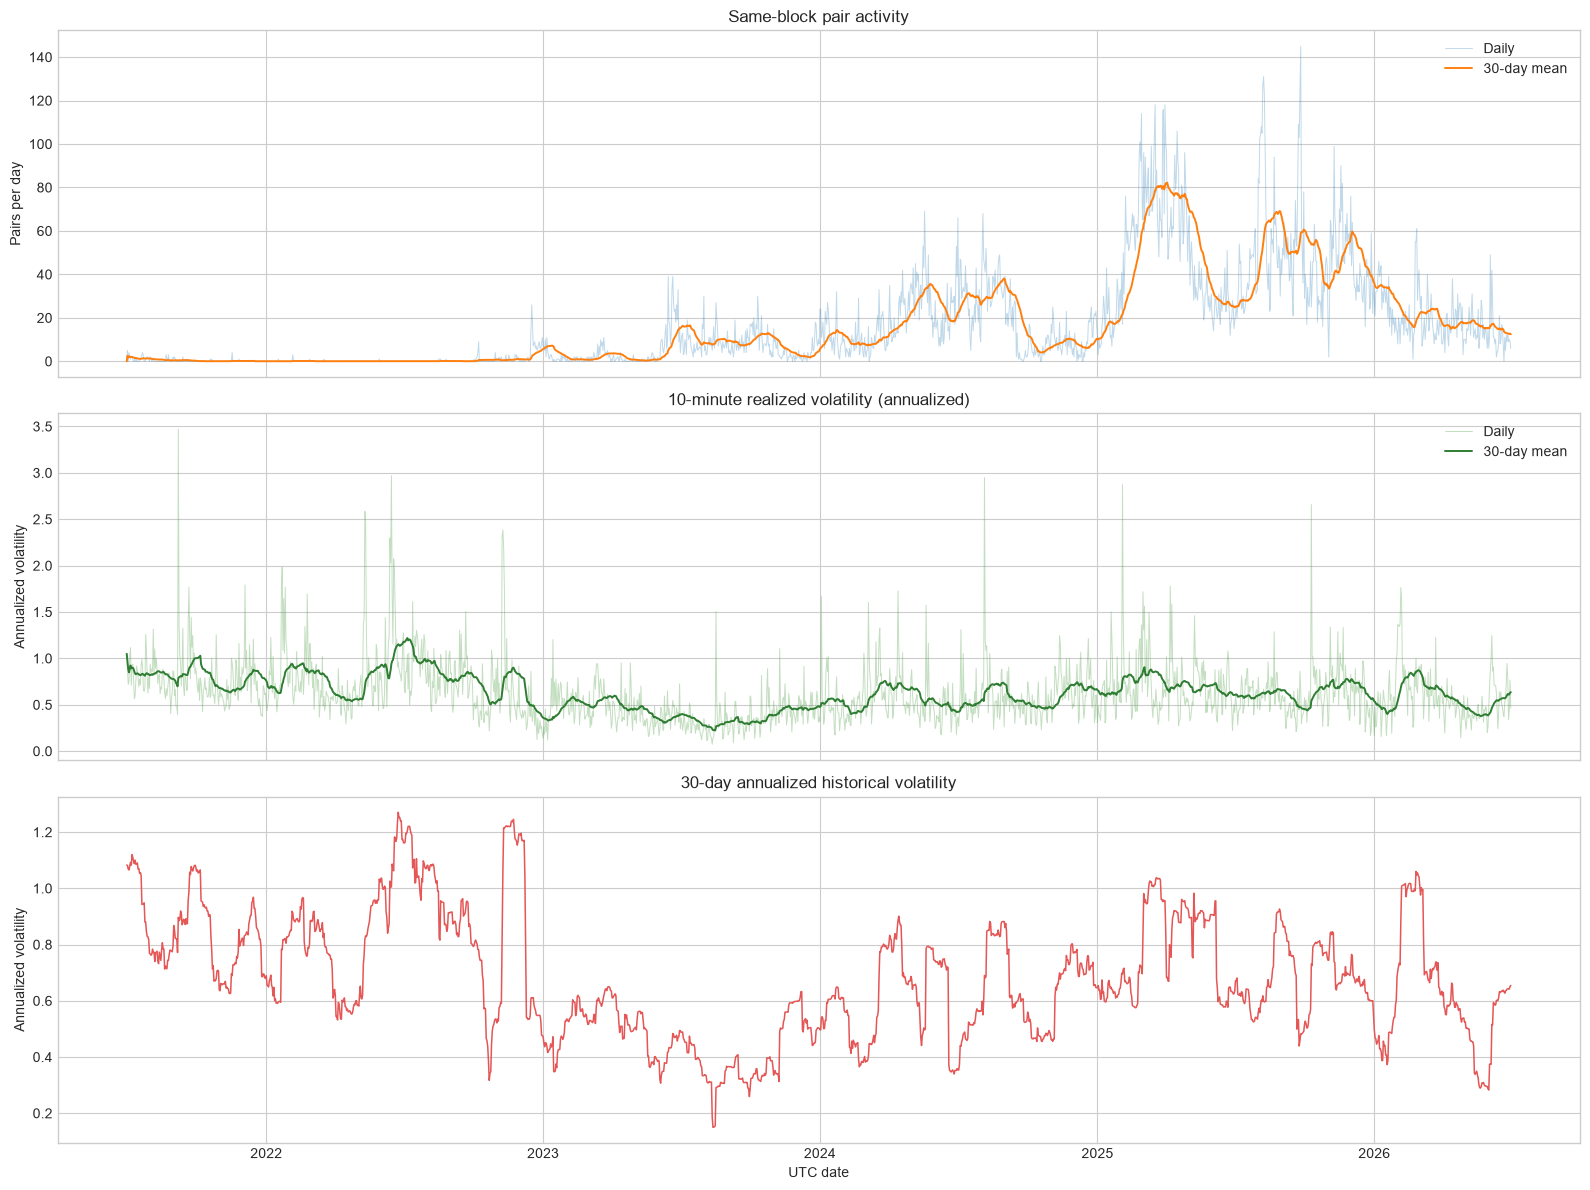

In [15]:
same_block_time_series = same_block_volatility.sort_values('date').copy()
same_block_time_series['same_block_count_30d_mean'] = same_block_time_series['same_block_count'].rolling(30, min_periods=1).mean()
same_block_time_series['realized_volatility_30d_mean'] = same_block_time_series['realized_volatility_10m_annualized'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
axes[0].plot(same_block_time_series['date'], same_block_time_series['same_block_count'], linewidth=0.7, alpha=0.28, label='Daily')
axes[0].plot(same_block_time_series['date'], same_block_time_series['same_block_count_30d_mean'], linewidth=1.4, label='30-day mean')
axes[0].set(title='Same-block pair activity', ylabel='Pairs per day')
axes[0].legend()
axes[1].plot(same_block_time_series['date'], same_block_time_series['realized_volatility_10m_annualized'], color='#54A24B', linewidth=0.7, alpha=0.35, label='Daily')
axes[1].plot(same_block_time_series['date'], same_block_time_series['realized_volatility_30d_mean'], color='#2E7D32', linewidth=1.4, label='30-day mean')
axes[1].set(title='10-minute realized volatility (annualized)', ylabel='Annualized volatility')
axes[1].legend()
axes[2].plot(same_block_time_series['date'], same_block_time_series['historical_volatility_30d'], color='#E45756', linewidth=1.1)
axes[2].set(title='30-day annualized historical volatility', ylabel='Annualized volatility', xlabel='UTC date')
plt.tight_layout(); plt.show()

## 11. FRED SOFR risk-free rate

FRED `SOFR`는 percent 단위 일별 연율이다. 주말·휴일은 직전 발표값을 forward-fill하며, 요청 결과가 비어 있거나 분석 시작일까지 선행값이 없으면 실패한다.

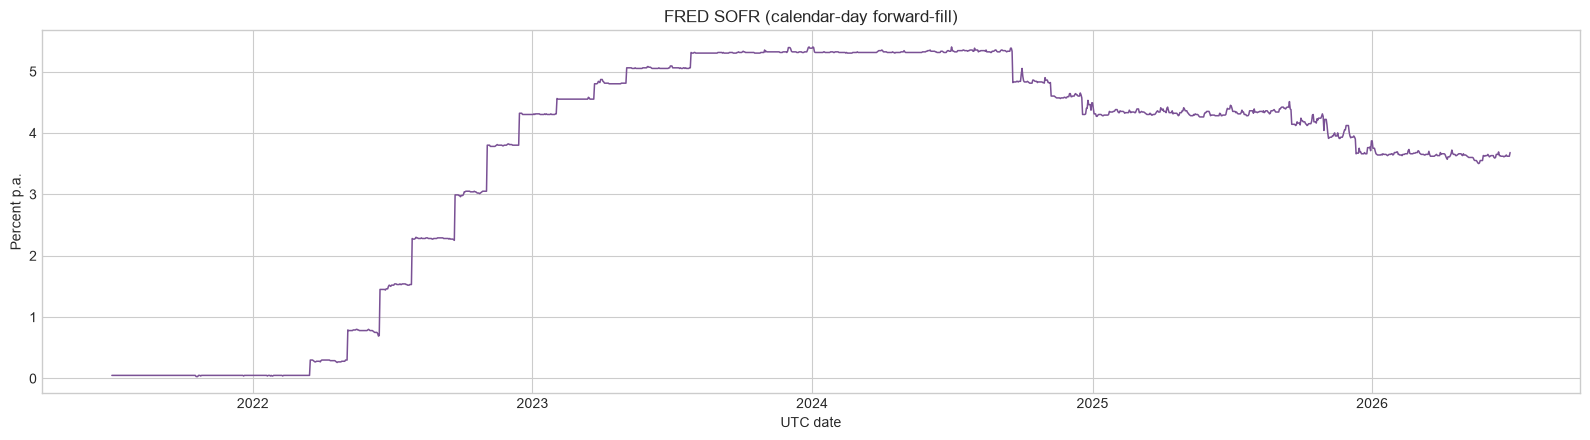

,sofr_percent
count,"1,826"
mean,3.57427
std,1.85412
min,0.03
25%,2.99
50%,4.3
75%,5.06
max,5.4


In [16]:
study_start = ANALYSIS_START
study_end = ANALYSIS_END - pd.Timedelta(days=1)
fred_start = (study_start - pd.Timedelta(days=7)).tz_localize(None)
fred_end = study_end.tz_localize(None)
sofr_raw = web.DataReader('SOFR', 'fred', fred_start, fred_end)
if sofr_raw.empty:
    raise RuntimeError('FRED returned no SOFR observations.')
sofr_raw.index = pd.to_datetime(sofr_raw.index, utc=True)
calendar = pd.date_range(study_start, study_end, freq='D')
sofr = sofr_raw.rename(columns={'SOFR': 'sofr_percent'}).reindex(calendar).ffill()
if sofr['sofr_percent'].isna().any():
    raise RuntimeError('SOFR coverage does not reach the study start.')
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(sofr.index, sofr['sofr_percent'], color='#7A5195', linewidth=1.1)
ax.set(title='FRED SOFR (calendar-day forward-fill)', xlabel='UTC date', ylabel='Percent p.a.')
plt.tight_layout(); plt.show()
display(sofr.describe())

## 12. 해석 시 주의점

- same-block은 행위 의도의 증명이 아니라 event-timing operational proxy다.
- open-pair liquidity $L$은 TVL이 아니며 tick range가 다른 position의 경제적 크기 비교에는 entry USDT value를 사용한다.
- observed realized fee에는 `fee_complete_exact` 조건을 충족한 position도 포함된다. 같은 계산식을 사용하며 별도 series나 benchmark로 나누지 않는다.
- exit Collect가 없는 row는 exit realized fee를 0으로 두며, accrued-but-uncollected fee가 0이라는 뜻은 아니다. 해당 count는 fee observation 표에 제시한다.
- 11개 overlap row는 임의 배분하지 않고 모든 analytical population count와 차트 전에 제거했다.
- 2021-07~2026-06 표본은 entry와 exit가 모두 기간 안에 있는 closed pair 조건부 표본이다. Open position과 장기 미종료 position의 경제적 모집단 전체를 나타내지는 않는다.
- 2026년 6월 진입 cohort는 snapshot 종료까지의 추가 관측기간이 상대적으로 짧으므로 daily lifetime 해석에 특히 주의한다.
- lifetime·wealth와 daily return 산점도의 y축 및 volatility 산점도의 x축은 1–99% 확대이지만, 표시 밖 tail도 Spearman 상관 계산에는 포함한다.
- volatility와 position count는 공통 시간추세, regime, 자기상관의 영향을 받으므로 산점도 상관을 인과관계로 해석하지 않는다.
- dailyized return은 특히 하루 미만 position에서 극단적이다. full quantile table과 1–99% 확대 그래프를 함께 확인한다.